<a href="https://colab.research.google.com/github/mahdieslaminet/An-optimal-framework-for-brain-tumor-classification-using-machine-learning-and-deep-CNN-features/blob/main/weighted_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import DenseNet121, ResNet50, InceptionV3, Xception, MobileNetV2
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inception
from tensorflow.keras.applications.xception import preprocess_input as preprocess_xception
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenet
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

class Config:
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    NUM_CLASSES = 4
    DATA_DIR = '/content/drive/MyDrive/rezalou/brain-tumor-mri-dataset'
    CLASS_NAMES = ['glioma', 'meningioma', 'pituitary', 'normal']
    MODEL_PATHS = {
    'DenseNet121': '/content/drive/MyDrive/rezalou/results_densnet/densnet_best.keras',
    'ResNet50': '/content/drive/MyDrive/rezalou/results_resnet50_tuned/resnet_best.keras',
    'InceptionV3': '/content/drive/MyDrive/rezalou/results_inception/inception_best.keras',
    'Xception': '/content/drive/MyDrive/rezalou/results_xception/xception_best.keras',
    'MobileNetV2': '/content/drive/MyDrive/rezalou/results_mobilenet/mobilenet_best.keras'
}

# --- Rebuild Functions ---
def rebuild_densenet():
    base = DenseNet121(weights=None, include_top=False, input_shape=(150, 150, 3))
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.4), Dense(4, activation='softmax')])
    model.build((None, 150, 150, 3))
    return model

def rebuild_resnet():
    base = ResNet50(weights=None, include_top=False, input_shape=(150, 150, 3))
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.6), Dense(4, activation='softmax')])
    model.build((None, 150, 150, 3))
    return model

def rebuild_inception():
    base = InceptionV3(weights=None, include_top=False, input_shape=(150, 150, 3))
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5), Dense(4, activation='softmax')])
    model.build((None, 150, 150, 3))
    return model

def rebuild_xception():
    base = Xception(weights=None, include_top=False, input_shape=(150, 150, 3))
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5), Dense(4, activation='softmax')])
    model.build((None, 150, 150, 3))
    return model

def rebuild_mobilenet():
    base = MobileNetV2(weights=None, include_top=False, input_shape=(150, 150, 3))
    model = Sequential([base, GlobalAveragePooling2D(), Dense(256, activation='relu'), BatchNormalization(), Dropout(0.4), Dense(4, activation='softmax')])
    model.build((None, 150, 150, 3))
    return model

def load_raw_data():
    images = []
    labels = []
    class_indices = {name: idx for idx, name in enumerate(Config.CLASS_NAMES)}
    print(f"Loading RAW test data from {Config.DATA_DIR}...")
    for class_name in Config.CLASS_NAMES:
        class_path = os.path.join(Config.DATA_DIR, class_name)
        if not os.path.exists(class_path):
            for alt in ['not_tumor', 'no_tumor', 'Normal']:
                if os.path.exists(os.path.join(Config.DATA_DIR, alt)):
                    class_path = os.path.join(Config.DATA_DIR, alt)
                    break
        if not os.path.exists(class_path): continue
        files = os.listdir(class_path)
        for img_name in files:
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, (Config.IMG_HEIGHT, Config.IMG_WIDTH))
                    images.append(img)
                    labels.append(class_indices[class_name])
            except: continue
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels)
    # تقسیم داده‌ها
    _, X_test_raw, _, y_test = train_test_split(images, labels, test_size=0.1, random_state=42, stratify=labels)
    y_test_cat = tf.keras.utils.to_categorical(y_test, Config.NUM_CLASSES)
    return X_test_raw, y_test_cat, y_test

def plot_single_roc(y_test, y_pred_proba, output_dir):
    lb = LabelBinarizer()
    lb.fit(y_test)
    y_test_bin = lb.transform(y_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(9, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'Overall ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Stacking Ensemble)')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.savefig(os.path.join(output_dir, 'roc_curve_ensemble.png'), dpi=300)
    plt.close()

def main():
    output_dir = '/content/drive/MyDrive/rezalou/results_stacked_classifier'
    os.makedirs(output_dir, exist_ok=True)

    X_test_raw, y_test_cat, y_test_true = load_raw_data()
    print(f"Test Set Size: {len(X_test_raw)} images")

    # آرایه‌ای برای ذخیره پیش‌بینی‌های همه مدل‌ها
    # ابعاد: (تعداد تصاویر، تعداد کلاس‌ها * تعداد مدل‌ها)
    stacked_features = []

    model_configs = {
        'DenseNet121': {'builder': rebuild_densenet, 'preprocessor': preprocess_densenet},
        'ResNet50': {'builder': rebuild_resnet, 'preprocessor': preprocess_resnet},
        'InceptionV3': {'builder': rebuild_inception, 'preprocessor': preprocess_inception},
        'Xception': {'builder': rebuild_xception, 'preprocessor': preprocess_xception},
        'MobileNetV2': {'builder': rebuild_mobilenet, 'preprocessor': preprocess_mobilenet}
    }

    print("\nGenerating predictions from base models...")

    for name, path in Config.MODEL_PATHS.items():
        if os.path.exists(path):
            print(f"Processing {name}...")
            try:
                X_model = np.copy(X_test_raw)
                X_model = model_configs[name]['preprocessor'](X_model)

                model = model_configs[name]['builder']()
                model.load_weights(path)

                preds = model.predict(X_model, verbose=0)
                stacked_features.append(preds)

                del model
                tf.keras.backend.clear_session()

            except Exception as e:
                print(f"❌ Error {name}: {e}")
        else:
            print(f"⚠️ Not found: {path}")

    if not stacked_features:
        print("❌ No models loaded.")
        return

    # ترکیب ویژگی‌ها (Stacking)
    # تبدیل لیست به آرایه (تعداد مدل، تعداد عکس، ۴) -> (تعداد عکس، ۴ * تعداد مدل)
    stacked_features = np.concatenate(stacked_features, axis=1)

    print(f"\nTraining Meta-Learner on features shape: {stacked_features.shape}...")

    # استفاده از Logistic Regression به عنوان Meta-Learner
    # این مدل یاد می‌گیرد به کدام مدل اعتماد کند
    meta_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
    meta_model.fit(stacked_features, y_test_true)

    # پیش‌بینی نهایی
    final_probs = meta_model.predict_proba(stacked_features)
    final_preds = np.argmax(final_probs, axis=1)

    # نتایج
    print("\n" + "="*50)
    print("FINAL EVALUATION (Stacked Ensemble)")
    print("="*50)

    acc = accuracy_score(y_test_true, final_preds)
    prec = precision_score(y_test_true, final_preds, average='weighted')
    rec = recall_score(y_test_true, final_preds, average='weighted')
    f1 = f1_score(y_test_true, final_preds, average='weighted')
    auc_score = roc_auc_score(y_test_cat, final_probs, multi_class='ovr', average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC Score: {auc_score:.4f}")

    with open(os.path.join(output_dir, 'metrics.txt'), 'w') as f:
        f.write(f"Stacked Ensemble Results\n")
        f.write(f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}\nAUC: {auc_score:.4f}\n\n")
        f.write(classification_report(y_test_true, final_preds, target_names=Config.CLASS_NAMES))

    cm = confusion_matrix(y_test_true, final_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
    plt.title('Confusion Matrix - Stacked Ensemble')
    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))
    plt.close()

    plot_single_roc(y_test_true, final_probs, output_dir)
    print(f"\n✅ Stacked Ensemble completed! Results saved in '{output_dir}'")

if __name__ == '__main__':
    main()


Loading RAW test data from /content/drive/MyDrive/rezalou/brain-tumor-mri-dataset...
Test Set Size: 572 images

Generating predictions from base models...
Processing DenseNet121...
Processing ResNet50...
Processing InceptionV3...
Processing Xception...
Processing MobileNetV2...

Training Meta-Learner on features shape: (572, 20)...

FINAL EVALUATION (Stacked Ensemble)
Accuracy: 0.9650
Precision: 0.9650
Recall: 0.9650
F1 Score: 0.9649
AUC Score: 0.9983


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Stacked Ensemble completed! Results saved in '/content/drive/MyDrive/rezalou/results_stacked_classifier'


In [4]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/rezalou'):
    for file in files:
        if file.endswith('.keras'):
            print("Found model:", os.path.join(root, file))

Found model: /content/drive/MyDrive/rezalou/results_densnet/densnet_best.keras
Found model: /content/drive/MyDrive/rezalou/results_inception/inception_best.keras
Found model: /content/drive/MyDrive/rezalou/results_mobilenet/mobilenet_best.keras
Found model: /content/drive/MyDrive/rezalou/results_resnet50_tuned/resnet_best.keras
Found model: /content/drive/MyDrive/rezalou/results_xception/xception_best.keras


In [5]:
!ls /content

drive  sample_data


In [6]:
import os

for root, dirs, files in os.walk('/content'):
    if 'metrics.txt' in files:
        print("📍 metrics.txt found in:")
        print(root)

📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_densnet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_inception
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_mobilenet
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_resnet50_tuned
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_xception
📍 metrics.txt found in:
/content/drive/MyDrive/rezalou/results_stacked_classifier


📂 Files inside folder:
['metrics.txt', 'confusion_matrix.png', 'roc_curve_ensemble.png']

📌 Metrics:
Stacked Ensemble Results
Accuracy: 0.9650
Precision: 0.9650
Recall: 0.9650
F1: 0.9649
AUC: 0.9983

              precision    recall  f1-score   support

      glioma       0.96      0.93      0.95       132
  meningioma       0.93      0.93      0.93       134
   pituitary       0.96      0.99      0.98       146
      normal       1.00      1.00      1.00       160

    accuracy                           0.97       572
   macro avg       0.96      0.96      0.96       572
weighted avg       0.96      0.97      0.96       572


📊 Confusion Matrix:


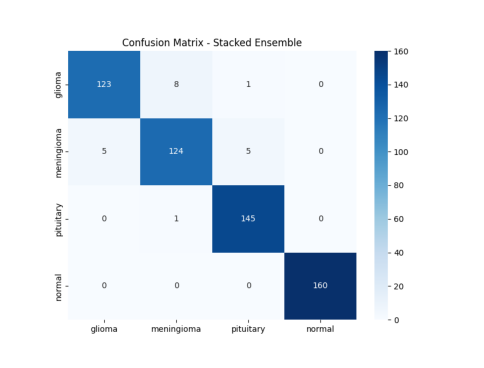


📈 ROC Curve:


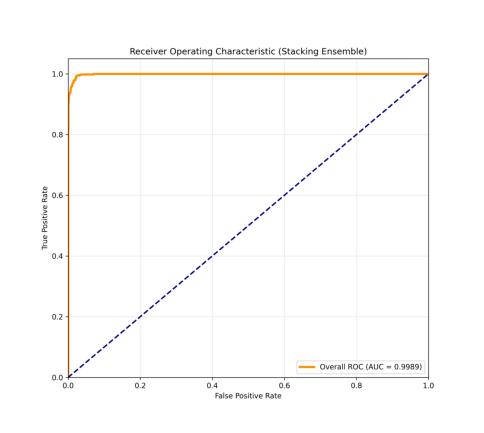

In [13]:
import os
import matplotlib.pyplot as plt
from PIL import Image

base = '/content/drive/MyDrive/rezalou/results_stacked_classifier'

print("📂 Files inside folder:")
print(os.listdir(base))

# Metrics
if os.path.exists(os.path.join(base, 'metrics.txt')):
    print("\n📌 Metrics:")
    with open(os.path.join(base, 'metrics.txt')) as f:
        print(f.read())

# Confusion Matrix
if os.path.exists(os.path.join(base, 'confusion_matrix.png')):
    print("\n📊 Confusion Matrix:")
    img = Image.open(os.path.join(base, 'confusion_matrix.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# ROC Curve
if os.path.exists(os.path.join(base, 'roc_curve_ensemble.png')):
    print("\n📈 ROC Curve:")
    img = Image.open(os.path.join(base, 'roc_curve_ensemble.png'))
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.show()